This notebook has been created by

s204248, Freja Tusindfryd Dollas & s204229, Søren Stange

# Comparative Social Structures in Fictional Universes: A Network and Text Analysis of the Wizarding World of Harry Potter and the Lord of the Rings

This is an explainer notebook made to show all of the programming which is the basis of the final project titled *Comparative Social Structures in Fictional Universes: A Network and Text Analysis of the Wizarding World of Harry Potter and the Lord of the Rings*.

#### Other files in the repositoire
This notebook utilises the results of two other notebooks in the repositoire. Namely 1) download_data.ipynb and 2) create_embedding.ipynb.

1) download_data.ipynb
In download_data.ipynb we crawl through the two fandom.com wiki-sites corresponding to **Harry Potter** (https://harrypotter.fandom.com/wiki/Harry_Potter) and **Lord of the Rings** (https://lotr.fandom.com/wiki/Main_Page). 

We crawl through each category found on the pages https://harrypotter.fandom.com/wiki/Harry_Potter/Category:Individuals and https://lotr.fandom.com/wiki/Main_Page/Category:Characters and extract all wiki pages found on these sites. These sites are then pruned taking only the ones containing infoboxes which relate to characters of the two universes. 

Two networks can then be created, one for the Harry Potter universe and one for the Lord of the Rings universe. Here the nodes of each network is the pages of characters and links between nodes are the hyperlinks in the wiki-pages content. We prune the network by removing all nodes which either don't link to any other or are not linked to by other pages. We then perform a final pruning by only selecting the largest weakly connected component for each network.

From all of the characters pages we extract info from the infoboxes and store these as node attributes along side the total number of words on each page. The attributes from the infoboxes we save are Blood-status (Pure-blood, half-blood, muggle) and House (Gryffendor, Slytherin, Ravenclaw, Hufflepuff) for Harry Potter and Culture and race for Lord of the Rings.

2) create_embedding.ipynb
In create_embedding.ipynb we use the implementation of the algorithm struc2vec from https://github.com/sebkaz/struc2vec/tree/master to create a vector representation of each node regarding their structural identity. This embedding will then be used in this notebook to determine role similarity between characters in the two character universes.

Lastly, a python script called util.py is created with usefull functions for this notebook.

#### Structure of the notebook
The rest of the notebook is structured as follows:
1) Network characterizations
2) Role similarity, data-mining, struc2vec
3) Sentiment analysis of the two universes

### Prelimary code

In [ ]:
# Import all relevant libraries and modules
import pickle, requests, math
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from gensim.models import KeyedVectors
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud
from collections import Counter

from util import *

In [54]:
# Load the data and networks
G       = load_network()
HP      = load_network('HP')
LOTR    = load_network('LOTR')

with open("data/Harry_Potter_Wiki_pages.pkl", "rb") as f: 
    HP_data = pickle.load(f)
with open("data/Lord_of_the_rings_Wiki_pages.pkl", "rb") as f:   
    LOTR_data = pickle.load(f)

combined_data = {}
for page in HP_data:
    combined_data[page['page_name']] = page['content']
for page in LOTR_data:
    combined_data[page['page_name']] = page['content']
    
with open("data/mapping.pkl", "rb") as f:
    mapping = pickle.load(f)
with open("data/reversed_mapping.pkl", "rb") as f:
    reversed_mapping = pickle.load(f)

emb = KeyedVectors.load_word2vec_format(f"data/embedding.emb", binary=False)

In [55]:
#download LabTM list for sentiment analysis

# Direct URL to the raw LabMT file
url = "https://journals.plos.org/plosone/article/file?id=10.1371/journal.pone.0026752.s001&type=supplementary"

# Download the file
r = requests.get(url)
r.raise_for_status()  # check if download worked
text = r.text

# Split into lines
lines = text.splitlines()

# Skip any lines before the header 
header_index = 0
for i, line in enumerate(lines):
    if line.startswith("word"):
        header_index = i
        break

# Parse the header line
columns = lines[header_index].split('\t')

# Parse the remaining lines into a list of dictionaries
data = []
for line in lines[header_index+1:]:
    values = line.split('\t')
    if len(values) == len(columns):
        data.append(dict(zip(columns, values)))

#  mapping word to happiness_average
word_scores = {row['word']: float(row['happiness_average']) for row in data}


### 1) Network characterizations

In [56]:
# Frejas kode her

### 2) Role similarity, data-mining, struc2vec

In [72]:
#Helper functions here
def create_X(emb = emb):
    word_vectors = []

    for key in emb.index_to_key:
        word_vectors.append((int(key), emb[key]))

    word_vectors = sorted(word_vectors, key = lambda x: x[0])

    X = np.array([snd for _, snd in word_vectors])
    return (X - np.mean(X, axis = 0)) / np.std(X, axis = 0)

def select_best_gmm_k(X, k_min=2, k_max=30):
    bic_scores = []
    gmms = []
    
    for k in range(k_min, k_max + 1):
        gmm = GaussianMixture(
            n_components=k,
            covariance_type='full',
            random_state=42
        )
        gmm.fit(X)
        bic = gmm.bic(X)
        bic_scores.append(bic)
        gmms.append(gmm)

    best_idx = np.argmin(bic_scores)
    best_k = k_min + best_idx
    best_gmm = gmms[best_idx]
    
    print(f"Best number of clusters (BIC): {best_k}")
    return best_k, best_gmm, bic_scores

def plot_pca_first_two(Z, labels):
    pca = PCA(n_components=2)
    Z_pca = pca.fit_transform(Z)

    labels = np.array(labels)

    unique_labels = np.unique(labels)

    plt.figure(figsize=(7, 7))

    for lab in unique_labels:
        idx = labels == lab
        plt.scatter(
            Z_pca[idx, 0],
            Z_pca[idx, 1],
            label=str(lab)
        )

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("PCA (first two components)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    return Z_pca

# Declare helper functions
def create_corpus(wikipedia_data, partition, filter_n = 5):
    corpus = {}
    if isinstance(partition, dict):
        for key, nodes in partition.items():
            corpus[key] = ''
            for node in nodes:
                corpus[key] += wikipedia_data.get(node, "")

    elif isinstance(partition, list):
        for i, nodes in enumerate(partition):
            key = f'Community {i+1}'
            corpus[key] = ''
            for node in nodes:
                corpus[key] += wikipedia_data.get(node, "")

    lemmatizer = WordNetLemmatizer()
    for key, item in corpus.items():
        tokens = word_tokenize(item)
        tokens = [word for word in tokens if word.isalnum()]
        tokens = [word.lower() for word in tokens]
        tokens = [lemmatizer.lemmatize(word) for word in tokens]
        word_counts = Counter(tokens)
        tokens = [word for word in tokens if word_counts[word] >= filter_n]
        token_counts = {word: count for word, count in word_counts.items() if count >= filter_n}
        token_counts = sorted(token_counts.items(), key=lambda x: x[1], reverse=True)
        corpus[key] = token_counts
    return corpus

def TF_IDF(corpus):
    corpus = corpus.copy()
    total_number_of_documents = len(corpus)
    word_list = {}
    for key, document in corpus.items():
        for word, amount in document:
            if word not in word_list:
                word_list[word] = 1
            else:
                word_list[word] += 1
    
    for key, document in corpus.items():
        total_number_of_words = sum([amount for _, amount in document])
        new_document = []
        for word, amount in document:
            TF = amount / total_number_of_words
            IDF = np.log(total_number_of_documents / word_list[word])
            new_document.append((word, amount, TF, IDF, TF * IDF))
            
        corpus[key] = sorted(new_document, key = lambda x: x[4], reverse=True)
    
    return corpus

def create_wordclouds(corpus, width = 400, height = 300):

    def normalize(x, a, b):
            return (x-b)/(a-b) * 1000
    n = len(corpus)
    if n == 0:
        print("Corpus is empty.")
        return

    # --- Figure layout ---
    rows = 2  # number of columns in the grid
    cols = math.ceil(n / rows)
    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 8))
    axes = axes.flatten() if n > 1 else [axes]

    # --- Create word clouds for each community ---
    for i, (key, token_counts) in enumerate(corpus.items()):
        # Convert list of tuples into a frequency dictionary
        TF_IDF_list = [TF_IDF for _,_,_,_,TF_IDF in token_counts]
        max_, min_ = max(TF_IDF_list), min(TF_IDF_list)
        
        freq_dict = []
        for word, _, _, _, TF_IDF in token_counts:
            freq_dict.append((word, normalize(TF_IDF, max_, min_)))
        freq_dict = dict(freq_dict)
        if not freq_dict:
            axes[i].set_visible(False)
            continue

        wc = WordCloud(
            width=width,
            height=height,
            background_color='white',
            colormap='viridis',
            random_state=42
        ).generate_from_frequencies(freq_dict)

        axes[i].imshow(wc, interpolation='bilinear')
        axes[i].set_title(key, fontsize=16)
        axes[i].axis('off')

    # --- Hide any unused subplots ---
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

def get_X_most_common_words(corpus, X = 10):
    for key, item in corpus.items():
        top_x = [word for word, _, _, _, _ in item[:X]]
        print(f'Group {key}: {top_x}')



Best number of clusters (BIC): 20


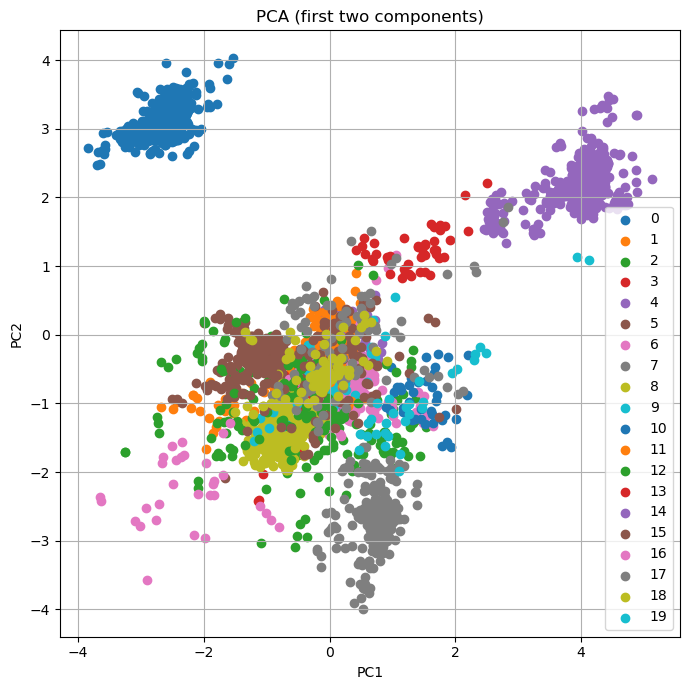

Group 0: ['cirion', 'lungorthin', 'madril', 'maglor', 'tertius', 'wbp', 'tulkas', 'nimrodel', 'baruffio', 'marhwini']
Group 1: ['puddifoot', 'mablung', 'dori', 'helmut', 'arador', 'gawrloc', 'damrod', 'sod', 'gabbey', 'wilkes']
Group 2: ['legolas', 'rosmerta', 'smaug', 'éowyn', 'ranrok', 'faramir', 'cadogan', 'lorgan', 'griphook', 'finrod']
Group 3: ['cole', 'arwen', 'imrahil', 'torvus', 'ori', 'celeborn', 'amrod', 'bem', 'eärnur', 'bane']
Group 4: ['gollum', 'thranduil', 'balin', 'ælfwine', 'karkus', 'skender', 'bombur', 'glaurung', 'gorbag', 'circus']
Group 5: ['rowesley', 'frtl', 'rimney', 'erkenbrand', 'swoopstikes', 'garnuff', 'egalmoth', 'quidditch', 'hl', 'performance']
Group 6: ['orgol', 'treebeard', 'mason', 'vána', 'gwaihir', 'bergil', 'dírhaval', 'daeron', 'théodred', 'bifur']
Group 7: ['berúthiel', 'charlatan', 'babbitty', 'goldberry', 'nessa', 'tinfang', 'gnarlak', 'brand', 'valacar', 'elmo']
Group 8: ['uin', 'whale', 'lurtz', 'elrond', 'gríma', 'aranarth', 'golfimbul', 'n

In [ ]:
# Struc2vec kode her
X = create_X()
best_k, best_gmm, bic_scores = select_best_gmm_k(X)
result = best_gmm.predict(X)
groups = {}
for x in set(result):
    idx = np.where(result == x)[0] + 1
    lst = [reversed_mapping[i] for i in idx]
    groups[x] = {'Names' : lst, 'index' : idx}

partition = {}
for x in set(result):
    idx = np.where(result == x)[0] + 1
    lst = [reversed_mapping[i] for i in idx]
    partition[x] = lst

Z_pca = plot_pca_first_two(X, result)

corpus = create_corpus(combined_data, partition)
c2 = TF_IDF(corpus)
get_X_most_common_words(c2)



### 3) Sentiment analysis

In [68]:
mapping["1980s_Hogwarts_Gobstones_Tournament_champion's_parents"]

2

In [ ]:
# Sentiment analyse her